<a href="https://colab.research.google.com/github/krishnasai272/DeepLearning/blob/main/Experiment-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.9815


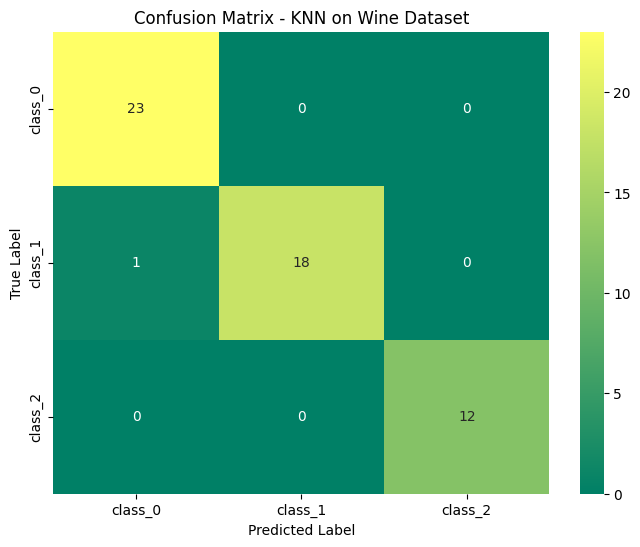

In [2]:
# performance of knn using wine dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load the dataset
wine = load_wine()
data = pd.DataFrame(data=wine.data, columns=wine.feature_names)
data['Target'] = wine.target

# 2. Split features and target
x = data.drop('Target', axis=1)
y = data['Target']

# 3. Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# 4. Feature Scaling (Crucial for KNN performance)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 5. Initialize and train the KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train_scaled, y_train)

# 6. Predict and evaluate
y_pred = model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 7. Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='summer',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - KNN on Wine Dataset')
plt.show()